In [1]:
import scanpy as sc

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [ ]:
adata_path = large_data_dir + 'GBM_BC002_genotyped.h5ad'

adata = sc.read_h5ad(adata_path)

tumor_normal_labels = pd.read_csv('../output/tumor_normal_labels_infercnv.txt', sep='\t', index_col=0)
adata.obs['tumor_normal_infercnv'] = tumor_normal_labels.loc[adata.obs_names, 'infercnv']

In [3]:
cluster_tumor_stats = adata.obs.groupby(['pheno_leiden', 'tumor_normal_infercnv']).size().unstack(fill_value=0)
cluster_tumor_stats['percent_tumor'] = (cluster_tumor_stats['tumor'] / cluster_tumor_stats.sum(axis=1) * 100).round(2)
cluster_tumor_stats.sort_values('percent_tumor', ascending=False)

tumor_clusters = cluster_tumor_stats[cluster_tumor_stats['percent_tumor'] >= 90].index.tolist()
normal_clusters = cluster_tumor_stats[cluster_tumor_stats['percent_tumor'] <= 10].index.tolist()


/tmp/ipykernel_2009151/20904890.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_tumor_stats = adata.obs.groupby(['pheno_leiden', 'tumor_normal_infercnv']).size().unstack(fill_value=0)


In [4]:
macrophage_genes = ['CD14', 'AIF1', 'FCER1G', 'FCGR3A', 'TYROBP', 'CSF1R'] ### Neftel 2019
oligodendrocyte_genes = ['MBP', 'TF', 'PLP1', 'MAG', 'MOG', 'CLDN11'] ### Neftel 2019
T_cell_genes = ['CD2', 'CD3D', 'CD3E', 'CD3G'] ### Neftel 2019
endothelial_genes = ['CD93', 'BGN', 'IL32', 'IGFBP7'] ### Bhaduri Nature 2020
neuronal_genes = ['RBFOX3','SLC17A7','SATB2'] ### excitatory neuron markers from Lake et al Science 2016

adata.obs['cell_type'] = pd.Categorical([np.nan] * adata.n_obs)

for gene_set, name in zip([macrophage_genes, oligodendrocyte_genes, T_cell_genes, endothelial_genes, neuronal_genes], ['Macrophage', 'Oligodendrocyte', 'T cell', 'Endothelial', 'Neuronal']):
    gf_utils.define_gene_score(adata, gene_set, name, subset=normal_clusters, rename=True)



In [5]:
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['Tumor'])
adata.obs.loc[adata.obs['pheno_leiden'].isin(tumor_clusters), 'cell_type'] = 'Tumor'

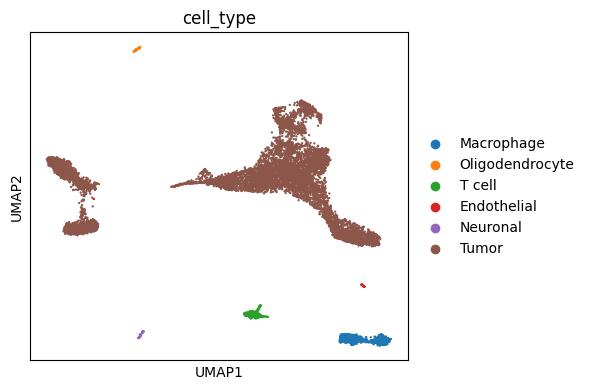

In [6]:
fig,ax = plt.subplots(figsize=(6,4))
sc.pl.umap(adata, color = 'cell_type', ax=ax, show=False)
plt.tight_layout()

In [7]:
### then label GBM states using Neftel gene sets
GBM_gene_sets = pd.read_excel('../data/Neftel_GBM_modules.xlsx')

col_names = []
modules = ['MES','AC','OPC','NPC']
for gene_set in modules:
    genes = GBM_gene_sets.loc[:,GBM_gene_sets.columns.str.contains(gene_set)].values.flatten()
    gf_utils.define_gene_score(adata, genes, gene_set, subset=tumor_clusters, rename=False)
    col_names.append('gene_score_' + gene_set)

In [8]:
# Add new categories first
new_categories = adata.obs.loc[adata.obs['tumor_normal_infercnv'] == 'tumor'][col_names].idxmax(axis=1).str.replace('gene_score_','').unique().tolist()
new_categories = [cat for cat in new_categories if cat not in adata.obs['cell_type'].cat.categories]
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(new_categories)

# Now assign the values
adata.obs.loc[adata.obs['cell_type'] == 'Tumor','cell_type'] = adata.obs.loc[adata.obs['cell_type'] == 'Tumor'][col_names].idxmax(axis=1).str.replace('gene_score_','')

# Drop unused categories from 'cell_type'
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()


In [9]:
palette = {
    # Malignant GBM subtypes (single bold cool scheme)
    'OPC': "#D7ECF3",  # very light icy blue
    'NPC': "#4EA8DE",  # vivid blue
    'MES': "#2A9D8F",  # saturated teal-green
    'AC':  "#1B4332",  # deep forest green

    # Non-malignant (independent categorical)
    'Macrophage':      "#C44536",  # brick red
    'T cell':          "#6A4C93",  # purple
    'Endothelial':     "#F4A261",  # orange
    'Oligodendrocyte': "#B08968",  # tan
    'Neuronal':       "#5F6C7B",  # neutral grey
}


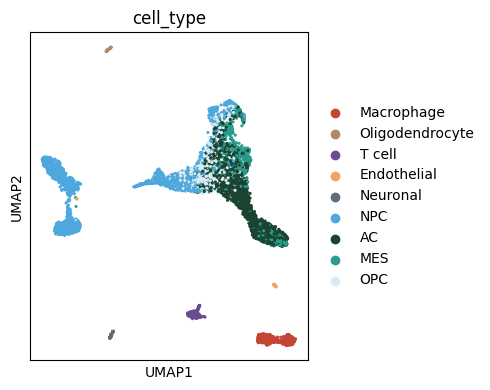

In [10]:
fig,ax = plt.subplots(figsize=(5,4))
sc.pl.umap(adata, color = 'cell_type', ax=ax, show=False, palette=palette,s=20)
plt.tight_layout()

plt.savefig('../plots/GBM_cell_type_umap.pdf')


In [11]:
adata.obs['cell_type'].to_csv('../output/GBM_cell_type_labels.txt', sep='\t')